In [1]:
# PATHS TO CHANGE
data_path = '/Users/ansonliu/Github/vision_proc_networks/data'  # path to data dir

In [2]:
import os
import requests

import torch
import torchvision.transforms as transforms

from PIL import Image, ImageOps
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_distances

import cornet

In [3]:
original_torch_load = torch.load

def cpu_torch_load(*args, **kwargs):
    kwargs['map_location'] = torch.device('cpu')
    return original_torch_load(*args, **kwargs)

torch.load = cpu_torch_load

model = cornet.cornet_s(pretrained=True)
model.eval()

print(model)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])  # TODO: conv 2 as output

/Users/ansonliu/Github/vision_proc_networks/.venv/lib/python3.12/site-packages/torch/serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


DataParallel(
  (module): Sequential(
    (V1): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (nonlin1): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (nonlin2): ReLU(inplace=True)
      (output): Identity()
    )
    (V2): CORblock_S(
      (conv_input): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (skip): Conv2d(128, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (norm_skip): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv1): Conv2d(128, 512, kernel_size=(1, 1), str

In [4]:
import os
image_dir = Path(os.path.join(data_path, 'samples'))
image_paths = list(image_dir.glob("*"))

for image_path in image_paths:
    print(image_path)

/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7468.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7469.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7467.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7670.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7466.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7464.jpg
/Users/ansonliu/Github/vision_proc_networks/data/samples/IMG_7465.jpg


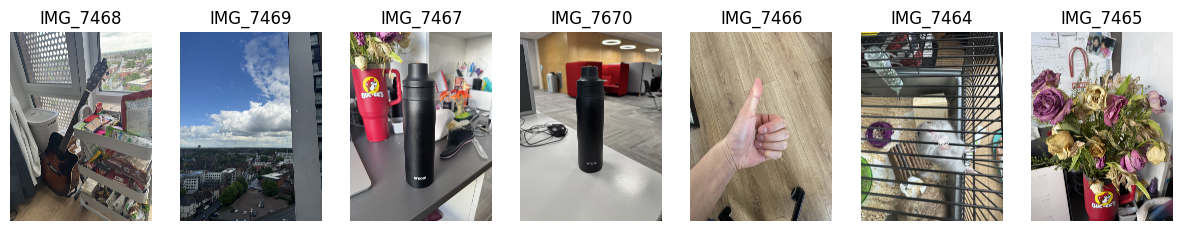

In [5]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(15,5))

for ax, path in zip(axes, image_paths):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    ax.imshow(img)
    ax.set_title(path.stem)
    ax.axis("off")

plt.show()

In [6]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

v1_layer = model.module.V1.register_forward_hook(get_activation("V1"))
v2_layer = model.module.V2.register_forward_hook(get_activation("V2"))
v4_layer = model.module.V4.register_forward_hook(get_activation("V4"))
it_layer = model.module.IT.register_forward_hook(get_activation("IT"))

In [7]:
img = Image.open(image_paths[3]).convert("RGB")
input_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)

# 3. Load label map
labels_json = requests.get("https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json").json()

probs = torch.nn.functional.softmax(output, dim=1)
top5_prob, top5_idx = torch.topk(probs, 5)
print("Top 5 Predictions")
for i in range(5):
    idx = str(top5_idx[0][i].item())
    label = labels_json[idx][1]
    conf = top5_prob[0][i].item()
    print(f"{i+1}: {label:20} ({conf:.2%})")
    
print("\nActivation Info")
print(f"V1 Layer Shape: {activations['V1'].shape}")

Top 5 Predictions
1: espresso_maker       (27.13%)
2: barber_chair         (10.43%)
3: dumbbell             (8.09%)
4: hand_blower          (7.07%)
5: tripod               (5.38%)

Activation Info
V1 Layer Shape: torch.Size([1, 64, 56, 56])


In [8]:
for layer_name, act in activations.items():
    print(layer_name, act.shape)

V1 torch.Size([1, 64, 56, 56])
V2 torch.Size([1, 128, 28, 28])
V4 torch.Size([1, 256, 14, 14])
IT torch.Size([1, 512, 7, 7])


In [9]:
layer_features = {
    "V1": [],
    "V2": [],
    "V4": [],
    "IT": []
}

image_names = []

for path in image_paths:

    img = Image.open(path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        _ = model(input_tensor)

    image_names.append(path.stem)

    for layer in layer_features.keys():
        feature = activations[layer]
        flattened = feature.flatten().cpu().numpy()
        layer_features[layer].append(flattened)

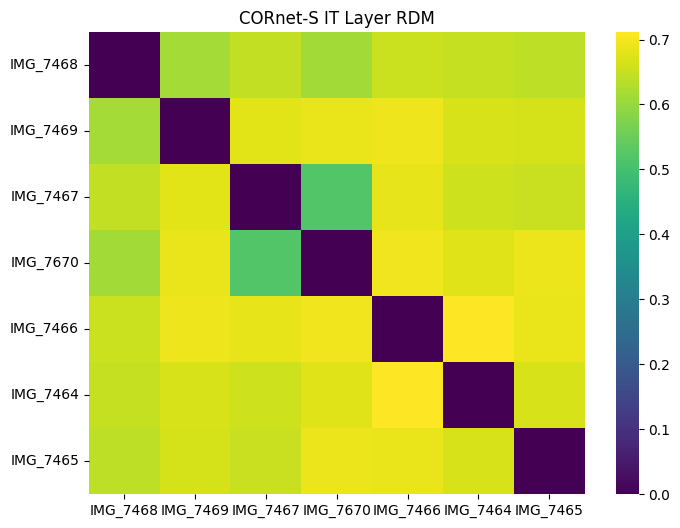

In [10]:
it_features = np.array(layer_features["IT"])
rdm = cosine_distances(it_features)

plt.figure(figsize=(8,6))
sns.heatmap(
    rdm,
    xticklabels=image_names,
    yticklabels=image_names,
    cmap="viridis"
)
plt.title("CORnet-S IT Layer RDM")
plt.show()

- similar images + 1 diff
- cornet RDM, all layers, to see how images progress
- eeg data input
- cornet-s diff models must be published to used

# EEG DATA EDA

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.stats as stats
import mne
import cv2
from numpy.linalg import lstsq


# eeg_data_path = '/Users/ansonliu/Library/CloudStorage/OneDrive-Personal/Masters/Dissertation/Example EEG Data'
eeg_data_path ='/Users/ansonliu/Downloads/Example EEG Data'

eeg_file = os.path.join(eeg_data_path, "dmrIf_mobilewalk.set")
video_file = os.path.join(eeg_data_path, "AC3.mp4")

hmax_file = os.path.join(eeg_data_path, "HMax_AC3_PCA90.mat")

In [12]:
raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)

n_pnts = raw.n_times  # 11737 samples
n_chan = raw.info['nchan']  # 67 channels
sfreq = raw.info['sfreq']  # 24 Hz

print(f"{n_chan} channels, {n_pnts} samples at {sfreq} Hz "
      f"({raw.times[-1]:.1f}s)")
print(f"Channels: {raw.ch_names[:5]} ... {raw.ch_names[-5:]}")

raw.set_channel_types({
    'x_dir': 'misc',
    'y_dir': 'misc',
    'z_dir': 'misc'
})

eeg_picks = mne.pick_types(raw.info, eeg=True)
misc_picks = mne.pick_types(raw.info, misc=True)

eeg_channels = [raw.ch_names[i] for i in eeg_picks]
accel_channels = [raw.ch_names[i] for i in misc_picks]

print(f"EEG channels: {len(eeg_channels)}")  # 64 now
print(f"Accelerometer (MISC) channels: {accel_channels}") # ['x_dir', 'y_dir', 'z_dir'] now

Reading /Users/ansonliu/Downloads/Example EEG Data/dmrIf_mobilewalk.fdt
Reading 0 ... 11736  =      0.000 ...   489.000 secs...
67 channels, 11737 samples at 24.0 Hz (489.0s)
Channels: ['Fp1', 'Fz', 'F3', 'F7', 'FT9'] ... ['F2', 'Iz', 'x_dir', 'y_dir', 'z_dir']
EEG channels: 64
Accelerometer (MISC) channels: ['x_dir', 'y_dir', 'z_dir']


/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_15925/1671758180.py:1: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)
/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_15925/1671758180.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(str(eeg_file), preload=True)
/var/folders/ct/wdj1ngds73n2slpf8tkgjc540000gn/T/ipykernel_15925/1671758180.py:11: RuntimeWarning: The unit for channel(s) x_dir, y_dir, z_dir has changed from V to NA.
  raw.set_channel_types({


In [13]:
hmax = sio.loadmat(hmax_file)
C1 = hmax['C1'][:n_pnts]  # (11737, 273) — trimmed from 17012
C2 = hmax['C2'][:n_pnts]  # (11737, 3)   — kept for later

print(f"C1: {C1.shape}  ({C1.shape[1]} PCA components)")
print(f"C2: {C2.shape}  ({C2.shape[1]} PCA components)")

C1: (11737, 273)  (273 PCA components)
C2: (11737, 3)  (3 PCA components)


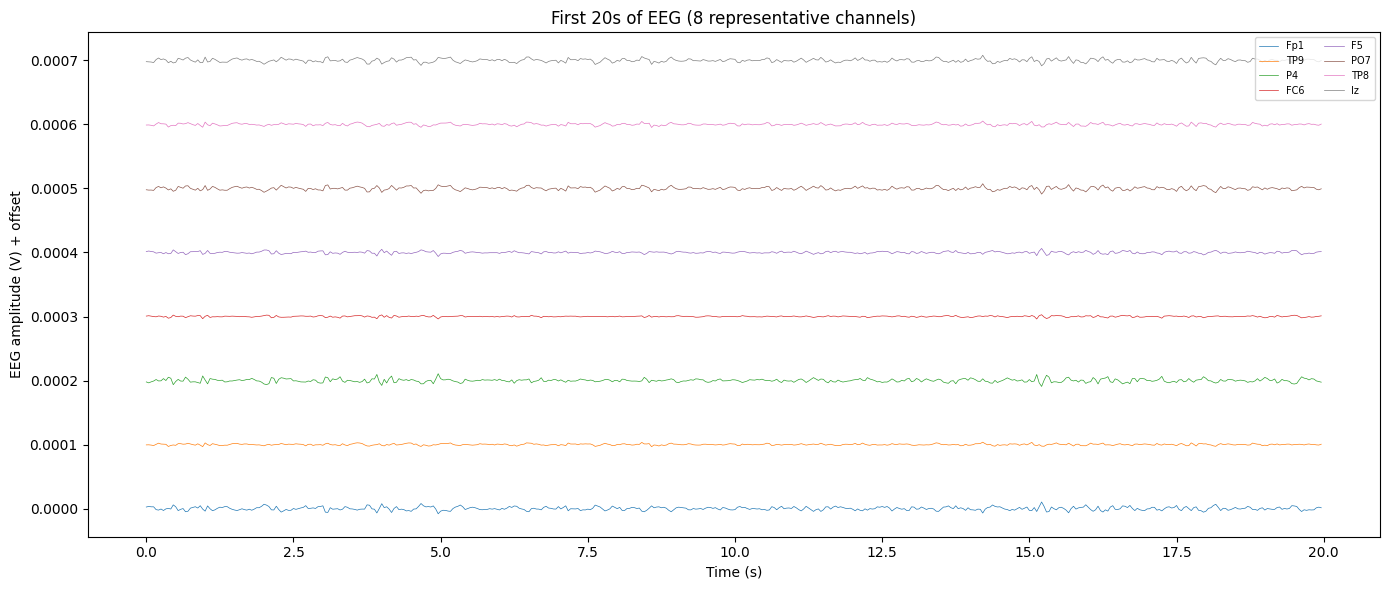

In [14]:
eeg_data = raw.get_data()  # (67, 11737), volts

fig, ax = plt.subplots(figsize=(14, 6))
t = raw.times
s_start, s_end = 0, int(20 * sfreq)  # first 20 seconds

# show 8 evenly-spaced EEG channels for readability
for i, ch_idx in enumerate(np.linspace(0, 63, 8, dtype=int)):
    offset = i * 100e-6
    ax.plot(t[s_start:s_end], eeg_data[ch_idx, s_start:s_end] + offset,
            linewidth=0.5, label=raw.ch_names[ch_idx])
ax.set_xlabel("Time (s)")
ax.set_ylabel("EEG amplitude (V) + offset")
ax.set_title("First 20s of EEG (8 representative channels)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

In [15]:
cap = cv2.VideoCapture(str(video_file))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video: {n_frames} frames at {fps} fps ({n_frames/fps:.1f}s, {width}×{height})")
print(f"EEG: {raw.n_times} samples at {raw.info['sfreq']} Hz ({raw.times[-1]:.1f}s)")
print(f"HMax C1: {C1.shape[0]} feature rows")
print(f"HMax C2: {C2.shape[0]} feature rows")

# the critical sanity check
counts = {"EEG samples": raw.n_times, "Video frames": n_frames, "C1 rows": C1.shape[0], "C2 rows": C2.shape[0]}
if len(set(counts.values())) == 1:
    print("\n All counts match — sample-by-sample alignment holds.")
else:
    print(f"\n MISMATCH: {counts}")

Video: 17012 frames at 25.0 fps (680.5s, 288×480)
EEG: 11737 samples at 24.0 Hz (489.0s)
HMax C1: 11737 feature rows
HMax C2: 11737 feature rows

 MISMATCH: {'EEG samples': np.int64(11737), 'Video frames': 17012, 'C1 rows': 11737, 'C2 rows': 11737}


In [16]:
N_OFFSETS = 10

r_data = np.zeros((n_chan, N_OFFSETS))  # adjusted R squared
f_data = np.zeros((n_chan, N_OFFSETS))  # F-statistic
p_data = np.zeros((n_chan, N_OFFSETS))  # p-value

for offs in range(N_OFFSETS):
    for elec in range(n_chan):
        chanz = eeg_data[elec, offs:]  # EEG starting at sample offs
        vfeats = C1[:n_pnts - offs]  # C1 truncated to match length

        # +/- 2 SD outlier removal (per-channel, per-offset, matches MATLAB)
        thr = 2 * chanz.std() + chanz.mean()
        keep = (chanz <= thr) & (chanz >= -thr)
        chanz = chanz[keep]
        vfeats = vfeats[keep]

        # OLS with intercept
        n, p = vfeats.shape
        X = np.column_stack([np.ones(n), vfeats])
        beta, *_ = lstsq(X, chanz, rcond=None)
        y_pred = X @ beta

        # adjusted R squared — matches MATLAB's mdl.Rsquared.Adjusted
        ss_res = np.sum((chanz - y_pred) ** 2)
        ss_tot = np.sum((chanz - chanz.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

        # omnibus F-test (full model vs intercept-only) — matches mdl.devianceTest
        ms_model = (ss_tot - ss_res) / p
        ms_resid = ss_res / (n - p - 1)
        f_stat = ms_model / ms_resid if ms_resid > 0 else 0.0
        p_val = 1 - stats.f.cdf(f_stat, p, n - p - 1)

        r_data[elec, offs] = adj_r2
        f_data[elec, offs] = f_stat
        p_data[elec, offs] = p_val

    lag_ms = offs * 1000 / sfreq
    print(f"Lag {lag_ms:5.1f} ms (offs={offs+1}): "
          f"max adj-R squared={r_data[:, offs].max():.4f}, "
          f"n significant (p<0.05) = {(p_data[:, offs] < 0.05).sum()}/{n_chan}")

Lag   0.0 ms (offs=1): max adj-R squared=0.0168, n significant (p<0.05) = 3/67
Lag  41.7 ms (offs=2): max adj-R squared=0.0149, n significant (p<0.05) = 5/67
Lag  83.3 ms (offs=3): max adj-R squared=0.0150, n significant (p<0.05) = 16/67
Lag 125.0 ms (offs=4): max adj-R squared=0.0158, n significant (p<0.05) = 19/67
Lag 166.7 ms (offs=5): max adj-R squared=0.0128, n significant (p<0.05) = 29/67
Lag 208.3 ms (offs=6): max adj-R squared=0.0112, n significant (p<0.05) = 6/67
Lag 250.0 ms (offs=7): max adj-R squared=0.0130, n significant (p<0.05) = 13/67
Lag 291.7 ms (offs=8): max adj-R squared=0.0140, n significant (p<0.05) = 14/67
Lag 333.3 ms (offs=9): max adj-R squared=0.0142, n significant (p<0.05) = 24/67
Lag 375.0 ms (offs=10): max adj-R squared=0.0139, n significant (p<0.05) = 15/67


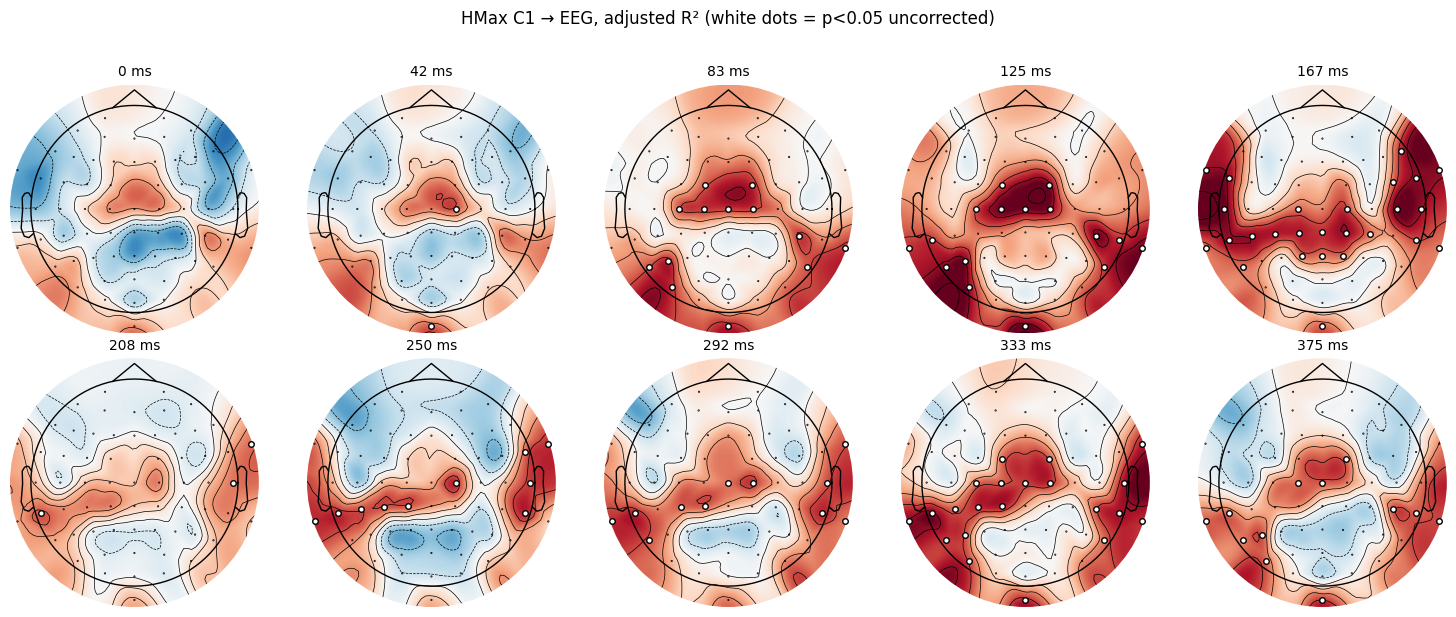

In [17]:
# select only the 64 channels with valid locations
eeg_picks = mne.pick_types(raw.info, eeg=True)
info_eeg = mne.pick_info(raw.info, eeg_picks)

# tile topomaps in a grid — adjust rows to fit N_OFFSETS
n_cols = 5
n_rows = int(np.ceil(N_OFFSETS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes_flat = axes.flatten() if N_OFFSETS > 1 else [axes]

# determine a sensible colour scale from the data (more informative than fixed ±0.02)
vmax = np.abs(r_data[eeg_picks]).max()

for offs in range(N_OFFSETS):
    ax = axes_flat[offs]
    r = r_data[eeg_picks, offs]
    p = p_data[eeg_picks, offs]
    mask = p < 0.05

    mne.viz.plot_topomap(
        r, info_eeg, axes=ax, show=False,
        vlim=(-vmax, vmax), cmap="RdBu_r",
        mask=mask,
        mask_params=dict(marker='o', markerfacecolor='w',
                         markeredgecolor='k', markersize=4),
    )
    lag_ms = offs * 1000 / sfreq
    ax.set_title(f"{lag_ms:.0f} ms", fontsize=10)

# hide unused subplots
for i in range(N_OFFSETS, len(axes_flat)):
    axes_flat[i].axis("off")

fig.suptitle("HMax C1 → EEG, adjusted R² (white dots = p<0.05 uncorrected)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

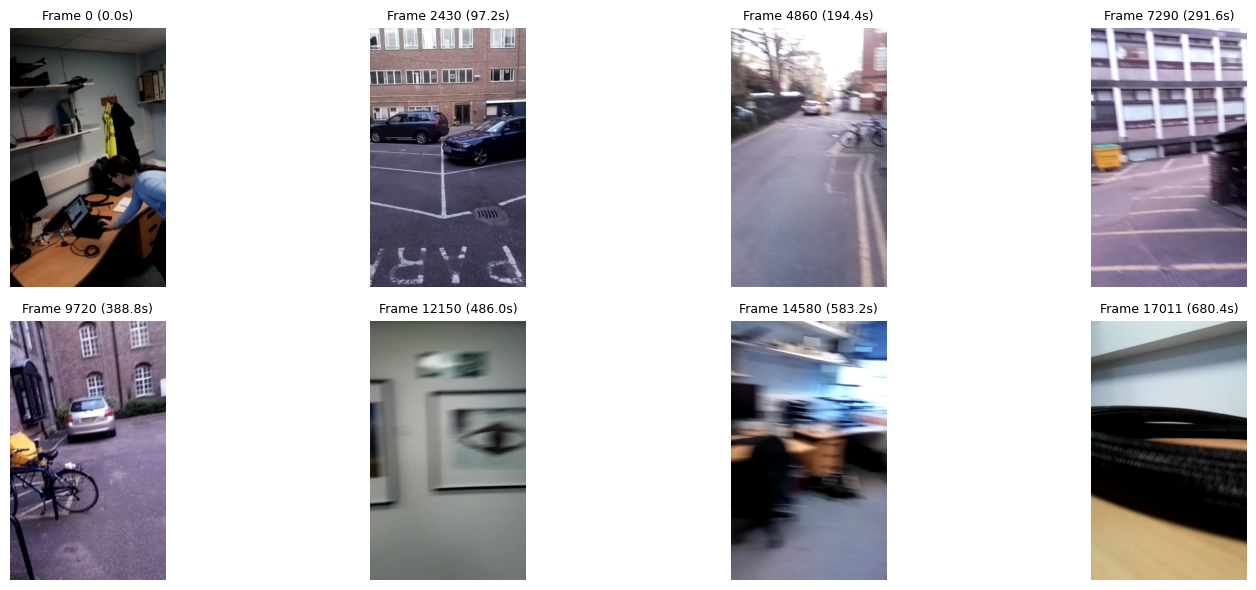

In [18]:
# view mp4
best_lag_idx = 4                              # offs=5 (167 ms) in your indexing
best_lag_ms = best_lag_idx * 1000 / sfreq
best_lag_s = best_lag_ms / 1000   # 0.167 seconds

def extract_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None)
    cap.release()
    return frames

sample_indices = np.linspace(0, n_frames - 1, 8, dtype=int)
sample_frames = extract_frames(video_file, sample_indices)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, frame, idx in zip(axes.flat, sample_frames, sample_indices):
    if frame is not None:
        ax.imshow(frame)
        ax.set_title(f"Frame {idx} ({idx/fps:.1f}s)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

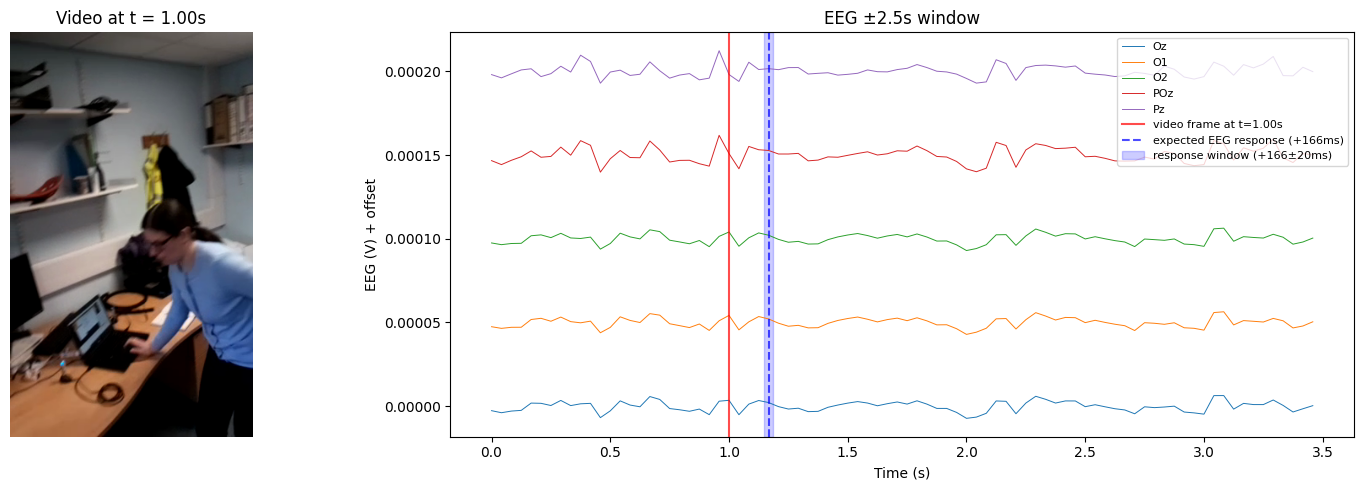

In [19]:
def show_at_time(t_sec, eeg_window=5.0):
    """
    Show the video frame at time t_sec alongside an EEG snippet centred on it.
    """
    # get video frame at this real-world time
    cap = cv2.VideoCapture(str(video_file))
    cap.set(cv2.CAP_PROP_POS_MSEC, t_sec * 1000)   # seek by time, not frame index
    ok, frame = cap.read()
    cap.release()
    if not ok:
        print(f"Could not read frame at {t_sec}s")
        return
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 2) extract the EEG window around this time
    sample = int(round(t_sec * sfreq))
    half_n = int(round(eeg_window / 2 * sfreq))
    s_lo = max(0, sample - half_n)
    s_hi = min(n_pnts, sample + half_n)

    # 3) plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                              gridspec_kw={"width_ratios": [1, 1.3]})

    axes[0].imshow(frame_rgb)
    axes[0].set_title(f"Video at t = {t_sec:.2f}s")
    axes[0].axis("off")

    # show a few occipital channels — adjust names if your montage differs
    occipital = [ch for ch in ["Oz", "O1", "O2", "POz", "Pz"] if ch in raw.ch_names]
    if not occipital:
        occipital = raw.ch_names[:5]

    times_window = raw.times[s_lo:s_hi]
    for i, ch_name in enumerate(occipital):
        ch_idx = raw.ch_names.index(ch_name)
        offset = i * 50e-6
        axes[1].plot(times_window, eeg_data[ch_idx, s_lo:s_hi] + offset,
                     linewidth=0.7, label=ch_name)

    # vertical cursor showing current time
    axes[1].axvline(t_sec, color="red", linewidth=1.5, alpha=0.7,
                    label=f"video frame at t={t_sec:.2f}s")
    # second cursor showing where the brain response to this frame appears
    axes[1].axvline(t_sec + best_lag_s, color="blue", linewidth=1.5,
                    alpha=0.7, linestyle="--",
                    label=f"expected EEG response (+{int(best_lag_ms)}ms)")
    axes[1].axvspan(t_sec + best_lag_s - 0.02,
                    t_sec + best_lag_s + 0.02,
                    color="blue", alpha=0.2,
                    label=f"response window (+{int(best_lag_ms)}±20ms)")

    
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("EEG (V) + offset")
    axes[1].set_title(f"EEG ±{eeg_window/2:.1f}s window")
    axes[1].legend(fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()

show_at_time(1.0)


In [ ]:
from ipywidgets import interact, FloatSlider

interact(
    show_at_time,
    t_sec=FloatSlider(min=0, max=n_pnts/sfreq - 0.1, step=0.5, value=100,
                       description="Time (s)", continuous_update=True),
    eeg_window=FloatSlider(min=1, max=20, step=1, value=5,
                            description="Window (s)")
)

interactive(children=(FloatSlider(value=100.0, description='Time (s)', max=488.94166666666666, step=0.5), Floa…

<function __main__.show_at_time(t_sec, eeg_window=5.0)>

# GLMnet with EEG Data